# 📗 그래프 알고리즘: 커뮤니티 탐지

33일차의 **PageRank** 가 "누가 중요한가"였다면, 이번에는 시선을 하나에서 **무리**로 옮깁니다. 서로 촘촘히 뭉친 무리를 찾아내는 **커뮤니티 탐지**입니다.

데이터는 **아시아 항공 노선망**(공항 767곳)입니다. 여기에는 **정답이 붙어 있습니다.** 공항마다 어느 국가·지역인지가 들어 있어(47개) 찾아낸 무리가 **실제 지도와 얼마나 맞는지 숫자로 확인**할 수 있습니다. 오늘 실습의 중심입니다.

## ⏪ 복습: 여기까지 배운 것

- **GDS 투영**: GDS 는 그래프를 메모리에 **투영**(분석용 사본)해야 씁니다. `gds.graph.project`·`gds.graph.list`·`gds.graph.drop`.
- **PageRank·매개 중심성**: 노드 하나의 중요도를 점수로 매기고 **순위**로 읽었습니다.
- **인덱스·제약**: 유일성 제약이 없으면 적재할 때 한 줄마다 전체를 훑습니다.
- 오늘은 같은 투영 위에서 **커뮤니티 탐지** 알고리즘을 돌립니다.

**오늘의 목표**

**1. 커뮤니티와 무방향 투영**
- [ ] (1-1) 노선망을 **UNDIRECTED(무방향)** 로 투영하는 이유를 알고, **차수와 상대 공항 수**가 다른 값이라는 것을 안다.

**2. Leiden 으로 커뮤니티 찾기**
- [ ] (2-1) **Leiden** 으로 커뮤니티를 찾고(`stream`), 크기 분포로 결과를 먼저 훑는다.
- [ ] (2-2) 찾은 커뮤니티를 `write` 로 그래프에 저장한다.

**3. 정답과 대조하기**
- [ ] (3-1) 찾은 커뮤니티를 **실제 국가·지역과 대조**해 **교차표**로 눈으로 본다.
- [ ] (3-2) **순도**를 읽는다.
- [ ] (3-3) **NMI** 로 전체를 한 숫자로 요약한다.

**4. 알고리즘 견주기**
- [ ] (4-1) **Louvain·라벨 전파**와 나란히 놓고 **모듈러리티**로 어느 분할이 나은지 판단한다.
- [ ] (4-2) 관계에 붙은 숫자를 `relationshipWeightProperty` 로 넘기는 법과, 커뮤니티 탐지와 최단 경로에서 그 값의 **뜻이 반대**라는 것을 안다.

**5. 흔들림과 해상도**
- [ ] (5-1) 결과가 **실행마다 흔들린다**는 것을 확인한다.
- [ ] (5-2) 재현하는 방법과 그 **한계**를 다룬다.
- [ ] (5-3) **해상도(gamma)** 를 다룬다.

**6. 큰 그래프를 그림으로**
- [ ] (6-1) 공항 767곳짜리 그래프를 **읽을 수 있는 그림**으로 줄인다(크기 막대·지도 산점도).
- [ ] (6-2) **메타그래프**로 커뮤니티 사이의 흐름을 본다.

아래 준비 셀을 **위에서부터** 실행하세요. 연결 → 초기화 → 투영 정리 → 항공 노선망 적재 → 무방향 투영 → 메일망 적재 순서입니다. Neo4j 는 **실습 전용 DB**에 연결하세요.

투영은 1-1 에서 **만드는 법**을 보려고 한 번 더 만듭니다.

In [18]:
# [제공 코드] Neo4j 연결: 교재 실습은 로컬 Neo4j (bolt://localhost:7689) 전용입니다.
import os
from dotenv import load_dotenv
from neo4j import GraphDatabase

# 1) 접속 정보 읽기: 교재는 100% 로컬 Neo4j 인스턴스 (7689) 강제
env_file = os.path.join(os.path.abspath(''), '.env')
if os.path.exists(env_file):
    load_dotenv(env_file, override=True)

# 상위 클라우드 Aura 환경변수가 상속되었을 경우 로컬 7689로 강제 치환
raw_uri = os.getenv('NEO4J_URI', '')
if not raw_uri or 'databases.neo4j.io' in raw_uri:
    NEO4J_URI = 'bolt://localhost:7689'
    NEO4J_USER = 'neo4j'
    NEO4J_PASSWORD = 'test0011'
else:
    NEO4J_URI = os.getenv('NEO4J_URI', 'bolt://localhost:7689')
    NEO4J_USER = os.getenv('NEO4J_USER', 'neo4j')
    NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', 'test0011')

# 2) 드라이버 연결
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()

# 3) 공용 Cypher 실행 헬퍼
def run_cypher(query, **params):
    with driver.session() as session:
        return [record.data() for record in session.run(query, **params)]

print('Neo4j 연결:', NEO4J_URI)


Neo4j 연결: bolt://localhost:7689


In [8]:
# [제공 코드] 실습 전용 DB 초기화: 지우기 전에 이 DB 가 맞는지 먼저 확인합니다.
UNIT_LABELS = ['Airport', 'Compound', 'DayType', 'Disease', 'ExDenseEvent', 'ExDisease', 'ExDomestic', 'ExDrug', 'ExEvent', 'ExForeign', 'ExIdKey', 'ExKing', 'ExKinng', 'ExNameKey', 'ExNodeKeyDemo', 'ExPerson', 'ExReign', 'ExScopeEvent', 'ExThrone', 'ExUniqueDemo', 'ExWorld', 'ExYear', 'FlatDrug', 'FlatKing', 'FlatOrder', 'Gene', 'IdKey', 'Line', 'Member', 'NameKey', 'NodeClass', 'NodeDay', 'NodeDrug', 'NodeKing', 'NodeMonth', 'NodeOrder', 'NodeYear', 'Person', 'PharmacologicClass', 'Station', 'SurveyDay', 'SurveyYear', 'Symptom', 'TempStation', 'TryDay', 'TryLine', 'TryStation']   # 이 단원이 만드는 레이블 전부(앞 일차가 남긴 것까지)

# 이 단원 것이 아닌 노드가 하나라도 있으면 지우지 않고 멈춥니다.
# .env 의 주소가 어긋나도 접속은 조용히 성공하므로, 지우기 전에 확인하는 수밖에 없습니다.
# all 로 보는 이유: any 로 보면 :Person:PatientRecord 처럼 한 레이블만 겹치는 남의 노드가 통과합니다
foreign = run_cypher("""
MATCH (n) WHERE size(labels(n)) = 0
   OR NOT all(label IN labels(n) WHERE label IN $unit_labels)
RETURN DISTINCT labels(n) AS labels LIMIT 5""", unit_labels=UNIT_LABELS)
if foreign:
    raise RuntimeError(
        f"{NEO4J_URI} 에 이 단원 것이 아닌 노드가 있습니다: {foreign}\n"
        "다른 실습이나 개인 데이터가 든 DB 로 보여 초기화를 멈췄습니다.\n"
        ".env 의 NEO4J_URI 가 실습 전용 DB 를 가리키는지 먼저 확인하세요.\n"
        "주소가 맞다면 위 레이블은 앞 실습이 남긴 것입니다. UNIT_LABELS 에 더하고 다시 실행하세요.")

# 여기까지 왔으면 이 DB 에는 이 단원이 만든 노드밖에 없습니다.
run_cypher("MATCH (n) DETACH DELETE n")   # DETACH: 노드에 붙은 관계까지 함께 지운다

print("초기화 완료:", NEO4J_URI, "· 남은 노드:", run_cypher("MATCH (n) RETURN count(n) AS n")[0]["n"])

RuntimeError: neo4j+ssc://a8a048c8.databases.neo4j.io 에 이 단원 것이 아닌 노드가 있습니다: [{'labels': ['DART_Company']}, {'labels': ['DART_Organization']}, {'labels': ['DART_Person']}, {'labels': ['DART_Disclosure']}]
다른 실습이나 개인 데이터가 든 DB 로 보여 초기화를 멈췄습니다.
.env 의 NEO4J_URI 가 실습 전용 DB 를 가리키는지 먼저 확인하세요.
주소가 맞다면 위 레이블은 앞 실습이 남긴 것입니다. UNIT_LABELS 에 더하고 다시 실행하세요.

In [ ]:
# [제공 코드] 남아 있는 GDS 투영(메모리 그래프)을 모두 정리: 이 셀은 실행만 하세요.
# 앞 실습의 사본이 남아 있으면 같은 이름으로 다시 투영할 때 충돌합니다.
for row in run_cypher("CALL gds.graph.list() YIELD graphName RETURN graphName"):
    run_cypher("CALL gds.graph.drop($g) YIELD graphName", g=row["graphName"])
print("남은 투영:", run_cypher("CALL gds.graph.list() YIELD graphName RETURN graphName"))

<img src="images/교안/항공_아시아망_구성.png" width="900">

**시연에 쓰는 그래프**입니다.

| 레이블 | 뜻 | 속성 |
|---|---|---|
| `:Airport` | 공항 767곳 | `iata` 공항 코드 · `name`·`city` 이름과 도시 · `country` 국가·지역 47종 · `lat`·`lon` 좌표 |

| 관계 | 잇는 것 | 속성 |
|---|---|---|
| `ROUTE` | 공항 → 공항 (방향별 8,045건) | `km` 두 공항 사이 거리 · `hours` km/800 + 1 · `airlines` 운항 항공사 수 |

> **`km`·`hours` 는 원본에 없는 값입니다.** `km` 은 두 공항 좌표로 계산했고, `hours` 는 `km/800 + 1` 로 정했습니다.

> 출처: OpenFlights(ODbL). **2014년 6월에 갱신이 멈춘 자료**라 시간표가 아니라 노선 유무만 담겨 있습니다. `country` 는 원본 표기라 대만·홍콩·마카오가 따로 있어 **국가·지역**이라고 부릅니다.

In [21]:
# [제공 코드] 아시아 항공 노선망 적재: 이 셀은 실행만 하세요(실습에 쓸 그래프를 만듭니다).
import pandas as pd

# 공항 767행, 노선 8,045행을 CSV 에서 읽습니다.
airports = pd.read_csv("data/airports_asia_nodes.csv")   # iata, name, city, country, lat, lon
routes = pd.read_csv("data/airports_asia_edges.csv")     # from_iata, to_iata, km, hours, airlines

# iata 로 공항을 찾을 때 전체를 훑지 않도록 유일성 제약을 먼저 겁니다(인덱스가 함께 생깁니다).
run_cypher("CREATE CONSTRAINT airport_iata IF NOT EXISTS FOR (a:Airport) REQUIRE a.iata IS UNIQUE")

# 공항을 노드로 만듭니다.
run_cypher("""UNWIND $rows AS r
    CREATE (:Airport {iata: r.iata, name: r.name, city: r.city, country: r.country,
                      lat: r.lat, lon: r.lon})""", rows=airports.to_dict("records"))

# 노선을 관계로 잇습니다. 왕복이면 CSV 에 두 행이 있어 관계도 둘이 됩니다.
run_cypher("""UNWIND $rows AS r
    MATCH (a:Airport {iata: r.from_iata}), (b:Airport {iata: r.to_iata})
    CREATE (a)-[:ROUTE {km: r.km, hours: r.hours, airlines: r.airlines}]->(b)""",
           rows=routes.to_dict("records"))

print("공항:", run_cypher("MATCH (a:Airport) RETURN count(a) AS n")[0]["n"],
      "· 노선 관계(방향별):", run_cypher("MATCH (:Airport)-[r:ROUTE]->() RETURN count(r) AS n")[0]["n"])

ConstraintError: {neo4j_code: Neo.ClientError.Schema.ConstraintValidationFailed} {message: Node(8320) already exists with label `Airport` and property `iata` = 'AAN'} {gql_status: 22N79} {gql_status_description: error: data exception - property uniqueness constraint violated. Property uniqueness constraint violated: Node(8320) already exists with label `Airport` and property `iata` = 'AAN'.}

In [22]:
# [제공 코드] 아시아 항공 노선망을 무방향으로 투영합니다: 이 셀은 실행만 하세요.
# 기존 air 투영이 있다면 제거합니다.
run_cypher("CALL gds.graph.drop('air', false) YIELD graphName")

# 노선은 방향이 있지만 '어느 공항끼리 이어져 있는가'에는 방향이 의미가 없어 UNDIRECTED 로 만듭니다.
stats = run_cypher('''
    CALL gds.graph.project('air', 'Airport',
      {ROUTE: {orientation: 'UNDIRECTED', properties: ['km', 'hours', 'airlines']}})
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount''')
print(stats[0])

{'graphName': 'air', 'nodeCount': 767, 'relationshipCount': 16090}


<img src="images/교안/메일_다섯부서_구성.png" width="900">

**따라하기에 쓰는 그래프**입니다. 시연과 레이블도 관계 이름도 달라 한 DB 에 함께 둬도 섞이지 않습니다.

| 레이블 | 뜻 | 속성 |
|---|---|---|
| `:Member` | 구성원 194명 | `employee_id` 익명 사번 · `dept` 부서 5종 |

| 관계 | 잇는 것 | 속성 |
|---|---|---|
| `MAILED` | 구성원 → 구성원 (방향별 2,439건) | 없음 |

> 출처: SNAP `email-Eu-core`. 유럽 연구기관의 사내 메일을 익명화한 자료에서 부서 다섯 곳만 잘라 냈습니다.

In [23]:
# [제공 코드] 다섯 부서 부분망 적재: 이 셀은 실행만 하세요(실습에 쓸 그래프를 만듭니다).
import pandas as pd

# 시연용 :Airport 와 레이블도 관계 이름도 달라 서로 섞이지 않습니다.
people = pd.read_csv("data/email_dept_group2_nodes.csv")   # employee_id, dept
mails = pd.read_csv("data/email_dept_group2_edges.csv")     # from_id, to_id

# employee_id 로 사람을 찾을 때 전원을 훑지 않도록 유일성 제약을 먼저 겁니다.
run_cypher("CREATE CONSTRAINT member_id IF NOT EXISTS FOR (p:Member) REQUIRE p.employee_id IS UNIQUE")

# 구성원을 노드로 만듭니다.
run_cypher("UNWIND $rows AS r CREATE (:Member {employee_id: r.employee_id, dept: r.dept})",
           rows=people.to_dict("records"))

# 메일을 관계로 잇습니다. 서로 주고받은 사이면 관계가 둘입니다(항공의 왕복 노선과 같은 모양입니다).
run_cypher("""UNWIND $rows AS r
    MATCH (a:Member {employee_id: r.from_id}), (b:Member {employee_id: r.to_id})
    CREATE (a)-[:MAILED]->(b)""", rows=mails.to_dict("records"))

print("구성원:", run_cypher("MATCH (p:Member) RETURN count(p) AS n")[0]["n"],
      "· 메일 관계:", run_cypher("MATCH (:Member)-[r:MAILED]->() RETURN count(r) AS n")[0]["n"])

구성원: 194 · 메일 관계: 2439


---
## 데이터 살펴보기

분석 전에 **규모와 모양부터 봅니다.** 공항 수·노선 관계 수·국가 가짓수를 확인합니다.

In [24]:
# 그래프의 크기를 한 번에 잰다: 공항 수, 국가·지역 수, 노선 관계 수
# COUNT { } 는 패턴 개수를 세는 문법. 노선은 방향이 있으므로 방향 그대로 센다
size_rows = run_cypher('''
    MATCH (a:Airport)
    RETURN count(a) AS airports,
           count(DISTINCT a.country) AS countries,
           COUNT { ()-[:ROUTE]->() } AS routes''')
print(size_rows[0])   # airports 는 공항 수, countries 는 국가·지역 수, routes 는 노선 관계 수(방향별)

{'airports': 767, 'countries': 47, 'routes': 8045}


> 노선 관계 **8,045개**는 **방향별** 수입니다. 인천에서 도쿄로 가는 노선과 도쿄에서 인천으로 오는 노선이 각각 한 개입니다. 다음 셀에서 **쌍**으로 세어 봅니다.

In [25]:
# 노선을 쌍으로 세어 왕복과 편도를 가른다
shape = run_cypher('''
    MATCH (a:Airport)-[:ROUTE]->(b:Airport)
    WITH COUNT { (b)-[:ROUTE]->(a) } > 0 AS round_trip   // 반대 방향 노선이 있는가
    WITH count(*) AS directed,
         sum(CASE WHEN round_trip THEN 1 ELSE 0 END) / 2 AS round_trip_pairs,
         sum(CASE WHEN round_trip THEN 0 ELSE 1 END) AS one_way_pairs
    RETURN directed, round_trip_pairs + one_way_pairs AS pairs,
           round_trip_pairs, one_way_pairs''')
print(shape[0])   # directed 는 방향별 관계 수, pairs 는 공항 쌍 수, round_trip_pairs 는 왕복, one_way_pairs 는 편도

{'directed': 8045, 'pairs': 4070, 'round_trip_pairs': 3975, 'one_way_pairs': 95}


> 방향별 8,045건은 쌍으로 세면 **4,070쌍**입니다. 그중 **3,975쌍은 왕복**(관계 둘)이고 **95쌍은 한 방향뿐**입니다(예: ADE→RUH, AGR→HJR).

이것을 편도라고 부르겠습니다. 다만 **원본에 한 방향만 들어 있다**는 뜻이지 실제 편도 운항이라는 보장은 아닙니다.

In [26]:
# 노선이 없는 공항은 커뮤니티 탐지에서 저 혼자 한 커뮤니티가 된다. 이 데이터에 있는지 먼저 본다
# (a)--()  는 관계 타입도 방향도 가리지 않는다는 뜻이다(이웃이면 무엇이든)
alone = run_cypher("MATCH (a:Airport) WHERE COUNT { (a)--() } = 0 RETURN count(a) AS alone")
print('노선이 하나도 없는 공항:', alone[0]['alone'], '곳')

노선이 하나도 없는 공항: 0 곳


In [27]:
import pandas as pd

# 나라별로 공항이 몇 곳인지 세어 많은 순으로 받는다
country_rows = run_cypher('''
    MATCH (a:Airport)
    RETURN a.country AS country, count(*) AS airports
    ORDER BY airports DESC''')
country_size = pd.DataFrame(country_rows)

# 공항이 몇 나라에 퍼져 있고, 가장 많은 나라와 가장 적은 나라가 몇 곳인지 본다
most, least = country_size.iloc[0], country_size.iloc[-1]
print('국가·지역', len(country_size), '곳 ·',
      '가장 많은', most['country'], most['airports'], '곳 ·',
      '가장 적은', least['country'], least['airports'], '곳')

국가·지역 47 곳 · 가장 많은 China 167 곳 · 가장 적은 Singapore 1 곳


In [28]:
display(country_size.head(8))   # 공항이 많은 상위 8개만 본다

,country,airports
0,China,167
1,India,67
2,Japan,61
3,Indonesia,57
4,Russia,48
5,Iran,38
6,Philippines,35
7,Malaysia,32


> 중국이 167곳으로 가장 많고 인도(67곳)·일본(61곳)·인도네시아(57곳)·러시아(48곳)가 뒤를 잇습니다. 국가·지역 47개인데 공항은 **상위 몇 곳에 몰려 있습니다.** 3절 교차표에서 큰 나라 하나가 커뮤니티 하나를 거의 채우는 모습으로 다시 나옵니다.

In [29]:
# airlines 값이 몇일 때 노선이 몇 건인지 세어 이 속성의 분포를 본다
# airlines(그 노선을 운항하는 항공사 수)는 4절에서 커뮤니티 탐지의 가중치로 넘길 값이다
airline_rows = run_cypher('''
    MATCH ()-[r:ROUTE]->()
    RETURN r.airlines AS airlines, count(*) AS routes
    ORDER BY airlines''')
display(pd.DataFrame(airline_rows))   # 1 부터 13 까지 전부 본다(줄 수가 적다)

,airlines,routes
0,1,3805
1,2,1944
2,3,1006
3,4,553
4,5,327
5,6,197
6,7,97
7,8,58
8,9,23
9,10,28


> 관계에는 숫자가 셋 붙어 있습니다.

- **`airlines`**: 그 방향을 **운항하는 항공사 수**입니다. 한 곳뿐인 노선이 3,805건으로 가장 많고 평균 2.17개입니다. 항공사가 가장 많은 노선은 푸껫(HKT)과 방콕(BKK) 사이로 **13개**입니다. 4-2 에서 **많이 이어질수록 가깝다**고 보는 가중치로 넘겨 봅니다.

  한 비행기를 여러 항공사가 저마다 자기 편명으로 파는 일이 있습니다(**코드셰어**). 원본 자료가 실제 운항사와 판매사를 구분하지 않아, 그런 항공사도 이 수에 함께 들어갑니다.
- **`km`**: **대권 거리**입니다. 지구가 둥글어 두 지점 사이 최단 거리는 지도 위 직선이 아니라 지구 표면을 따라 도는 곡선이고, 그 길이를 잰 값입니다(41km 에서 8,645km, 중앙값 1,037km).
- **`hours`**: `km/800 + 1`. 원본에 비행 시간이 없어, 대권 거리를 순항 800km/h 로 나눈 뒤 이착륙·환승 몫 1시간을 더해 만든 값입니다.

`km`·`hours` 는 **다음 교시**에서 최단 경로의 잣대로 씁니다. 이 교시에서는 `airlines` 만 씁니다.

---
# 1. 커뮤니티란 무엇이고, 왜 무방향으로 투영할까

<img src="images/교안/커뮤니티란_촘촘한_묶음.png" width="820">

### 커뮤니티란 무엇인가

**안쪽끼리는 빽빽하게 이어져 있고 바깥과는 드문드문 이어진 노드 무리**를 커뮤니티라고 합니다. 위 그림에서 동아시아 공항끼리는 노선이 빽빽한데, 동아시아와 남아시아를 잇는 노선은 몇 개뿐입니다.

"빽빽하다"는 말에는 **견줄 기준**이 필요합니다. 관계가 많기만 해서는 안 되고 **아무렇게나 이었을 때 기대되는 것보다 많아야** 합니다. 그 기준을 숫자 하나로 만든 것이 **모듈러리티**이고 4절에서 씁니다.

두 가지를 미리 짚어 둡니다.

- 좌표나 속성이 아니라 **연결만** 봅니다. 투영에 위경도를 싣지 않으니 공항이 어디에 있는지 몰라도 같은 답이 나옵니다.
- **정답이 하나로 정해지지 않습니다.** 어디까지 한 커뮤니티로 볼지는 해상도에 따라 달라집니다(5-3).

커뮤니티 탐지는 **나라 이름을 주지 않아도** 연결의 촘촘함만으로 이 커뮤니티를 찾아냅니다. 3절에서 찾은 커뮤니티를 실제 국가와 맞대 봅니다.

## 1-1. 노선망을 무방향으로 투영하기

### 문법: 무방향(UNDIRECTED) 투영
관계 `(a)-[:ROUTE]->(b)` 에는 방향이 있지만 "어느 공항끼리 이어져 있는가"에는 방향이 필요 없습니다. 그래서 `orientation: 'UNDIRECTED'` 를 줍니다. 권장이 아니라 **필수**입니다. 방향 투영을 Leiden 에 넘기면 **실행을 거부**합니다(`Leiden requires relationship projections to be UNDIRECTED`). 고칠 것은 알고리즘이 아니라 **투영**입니다.

관계 속성 `km`·`hours`·`airlines` 도 함께 싣습니다. 투영은 **그 순간의 사본**이라 나중에 쓸 값은 만들 때 실어 둬야 합니다.

In [30]:
# 아시아 항공 노선망을 무방향으로 투영합니다.
# 기존 air 투영이 있다면 제거합니다.
run_cypher("CALL gds.graph.drop('air', false) YIELD graphName")   # false: 없으면 그냥 넘어간다

# 노선은 방향이 있지만 '어느 공항끼리 이어져 있는가'에는 방향이 의미가 없어 UNDIRECTED 로 만듭니다.
stats = run_cypher('''
    CALL gds.graph.project('air', 'Airport',
      {ROUTE: {orientation: 'UNDIRECTED', properties: ['km', 'hours', 'airlines']}})
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount''')
print(stats[0])

{'graphName': 'air', 'nodeCount': 767, 'relationshipCount': 16090}


> `relationshipCount` **16,090** 은 적재한 관계 8,045개의 정확히 **두 배**입니다. 무방향 투영은 관계 하나를 양쪽 방향으로 저장합니다. 정상입니다.

그래서 **한 공항에 붙은 관계 수(차수)와 그 공항의 상대 공항 수는 다른 값**이 됩니다. 아래에서 둘을 나란히 세어 확인합니다.

In [31]:
# 관계 수(차수)와 상대 공항 수의 중앙값을 나란히 잰다
# 다음 교시의 degreeCutoff 는 '상대 수' 기준이라 어느 쪽인지 구분해 둬야 한다
spread = run_cypher('''
    MATCH (a:Airport)
    OPTIONAL MATCH (a)--(x:Airport)
    WITH a, COUNT { (a)--() } AS rels, count(DISTINCT x) AS partners   // rels 는 관계 수, partners 는 상대 공항 수
    RETURN percentileCont(rels, 0.5) AS median_rels,
           percentileCont(partners, 0.5) AS median_partners''')
print(spread[0])   # 왕복 노선을 둘로 세므로 관계 수 중앙값이 상대 수 중앙값보다 크다

{'median_rels': 6, 'median_partners': 4}


In [32]:
# 노선이 많은 공항(허브)일수록 두 값이 크게 벌어진다. 차수 상위 다섯 곳을 본다
hub_rows = run_cypher('''
    // --  는 관계 타입도 방향도 가리지 않는다는 뜻이다(이웃이면 무엇이든)
    MATCH (a:Airport)--(x:Airport)
    WITH a, count(*) AS degree, count(DISTINCT x) AS partners   // degree 는 관계 수, partners 는 상대 공항 수
    RETURN a.iata AS iata, a.city AS city, degree, partners
    ORDER BY degree DESC LIMIT 5''')
display(pd.DataFrame(hub_rows))

,iata,city,degree,partners
0,PEK,Beijing,313,157
1,CAN,Guangzhou,255,128
2,PVG,Shanghai,237,120
3,CTU,Chengdu,202,101
4,SIN,Singapore,196,98


> 노선이 가장 많은 베이징(PEK)은 차수가 **313** 인데 상대 공항은 **157곳**입니다. 왕복이면 관계가 둘이니 두 배에 가깝지만, 정확히 314(157 x 2)가 아닌 것은 상대 가운데 1곳과 **한 방향 노선만** 있기 때문입니다(앞에서 센 편도 95쌍).

**차수를 상대 수로 읽으면 두 배로 부풀려 보고하게 됩니다.** 그 숫자가 관계 수인지 상대 수인지 먼저 확인하세요.

### 🖐️ 함께 따라하기: 다섯 부서 부분망을 무방향으로 투영하기

메일도 노선처럼 방향이 있고 서로 주고받았으면 관계가 둘입니다. "누가 누구와 함께 일하는가"에는 방향이 필요 없으니 여기서도 무방향으로 투영합니다.

`:Member` 와 `MAILED` 로 **투영 이름 `'team'`** 을 만드세요. `orientation: 'UNDIRECTED'` 를 주고, 만든 뒤 `nodeCount`·`relationshipCount` 를 출력해 확인합니다. 이 데이터의 관계에는 숫자가 붙어 있지 않으므로 속성은 싣지 않습니다.

**확인 기준**: `nodeCount` 는 **194**, `relationshipCount` 는 **4,878**(적재한 2,439개의 두 배)입니다.

In [34]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 같은 이름의 투영이 남아 있을 수 있으니 gds.graph.drop('team', false) 로 먼저 내린다
# 2) gds.graph.project 로 'team' 을 만든다. 레이블은 'Member', 관계는 MAILED,
#    관계 설정에 orientation: 'UNDIRECTED' 를 준다
# 3) YIELD graphName, nodeCount, relationshipCount 를 받아 출력한다


run_cypher("CALL gds.graph.drop('team', false) YIELD graphName")   # false: team 투영이 없어도 에러가 발생 안함



result = run_cypher('''
    CALL gds.graph.project('team', 'Member',
      {MAILED: {orientation: 'UNDIRECTED'}})
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount''')

print(result[0])


{'graphName': 'team', 'nodeCount': 194, 'relationshipCount': 4878}


### ✅ 바로 확인 퀴즈

**1.** 노선망을 `UNDIRECTED` 로 투영하는 이유는?

<details><summary>정답 보기</summary>

"어느 쪽으로 가는 노선인가"가 아니라 "**서로 이어져 있는가**"를 보려는 것이기 때문입니다. 게다가 Leiden 은 방향 투영을 아예 거부합니다.

</details>

**2.** 적재한 관계는 8,045개인데 투영의 `relationshipCount` 는 16,090 입니다. 버그일까요?

<details><summary>정답 보기</summary>

아닙니다. 무방향 투영은 관계 하나를 양쪽 방향으로 각각 저장해서 정확히 두 배가 됩니다.

</details>

**3.** 베이징(PEK)의 차수는 313 인데 상대 공항은 157곳입니다. 왜 정확히 두 배(314)가 아닐까요?

<details><summary>정답 보기</summary>

상대 가운데 1곳과는 원본에 **한 방향 노선만** 있기 때문입니다. 왕복이면 관계가 둘이라 차수를 둘 올리지만, 한 방향뿐이면 하나만 올립니다.

</details>

---
# 2. Leiden 으로 커뮤니티 찾기

**Leiden** 은 지금 가장 널리 쓰이는 커뮤니티 탐지 알고리즘이라 이 단원의 기준으로 씁니다.

## 2-1. 커뮤니티를 찾고 크기 분포로 먼저 훑기

Leiden 은 Louvain 의 개선판으로, **속이 끊긴 커뮤니티**(같은 커뮤니티인데 그 안에서 서로 이어지지 않는 경우)가 생기지 않도록 보장합니다.

### 문법: `gds.leiden.stream`
```cypher
CALL gds.leiden.stream('투영이름')
YIELD nodeId, communityId
```
- `nodeId` 는 GDS 내부 번호입니다. `gds.util.asNode(nodeId)` 로 실제 노드를 꺼냅니다.
- `communityId` 는 **같은 커뮤니티에 같은 번호**라는 뜻일 뿐, 번호 자체에 의미는 없습니다.

In [35]:
# 커뮤니티를 찾는다. stream 은 그래프에 저장하지 않는다(저장은 뒤의 write)
comm_rows = run_cypher('''
    CALL gds.leiden.stream('air')
    YIELD nodeId, communityId
    RETURN gds.util.asNode(nodeId).iata AS iata,
           gds.util.asNode(nodeId).city AS city,
           gds.util.asNode(nodeId).country AS country,
           gds.util.asNode(nodeId).lat AS lat,   // 6절 지도에 그대로 찍는다
           gds.util.asNode(nodeId).lon AS lon,
           communityId AS community''')
community = pd.DataFrame(comm_rows)
print('찾은 커뮤니티 수:', community['community'].nunique())

찾은 커뮤니티 수: 8


In [36]:
display(community.head())

,iata,city,country,lat,lon,community
0,AAN,Al Ain,United Arab Emirates,24.2617,55.6092,9
1,AAT,Altay,China,47.7499,88.0858,5
2,AAY,Al Ghaidah Intl,Yemen,16.1917,52.1750,9
3,ABA,Abakan,Russia,53.7400,91.3850,0
4,ABD,Abadan,Iran,30.3711,48.2283,2


> **커뮤니티 번호는 0, 1, 2 … 로 이어지지 않습니다.** 이름표일 뿐이라 중간 번호가 비기도 하고 커뮤니티 수보다 큰 번호가 나오기도 합니다. Leiden 이 작은 커뮤니티를 합쳐 가며 쓰던 번호를 그대로 돌려주기 때문입니다. **번호의 크기나 순서에는 뜻이 없습니다.** "몇 번 커뮤니티인가" 가 아니라 "어느 공항끼리 같은 번호인가" 로 읽으세요.

이제 **크기 분포**를 봅니다. 개수만 보고 넘어가면 결과를 크게 오해합니다.

In [39]:
community['community'].value_counts()  

community
5     179
9     172
0     100
8      93
16     77
22     77
2      36
21     33
Name: count, dtype: int64

In [37]:
# 큰 것부터 늘어놓아야 쏠림이 보인다
sizes = community['community'].value_counts()   # 커뮤니티 번호 -> 공항 수, 많은 순
print('커뮤니티 수:', len(sizes))
print('크기(큰 순서):', sorted(sizes, reverse=True))

커뮤니티 수: 8
크기(큰 순서): [179, 172, 100, 93, 77, 77, 36, 33]


In [42]:
# 가장 작은 커뮤니티에는 어느 국가·지역이 들어 있는지 함께 본다
smallest = sizes.index[0]                      # value_counts 는 적은 쪽이 뒤에 온다
peek = community[community['community'] == smallest]
print('가장 작은 커뮤니티:', len(peek), '곳')

가장 작은 커뮤니티: 179 곳


In [43]:
print(peek['country'].value_counts().head())

country
China          166
Taiwan           8
South Korea      3
Hong Kong        1
Macau            1
Name: count, dtype: int64


> 커뮤니티는 여러 번 돌려 보면 **5개에서 9개** 사이가 나옵니다(가장 자주 나온 것은 8개). 가장 큰 커뮤니티는 **170곳에서 211곳** 사이입니다. 공항이 767곳이니 **가장 큰 커뮤니티 하나가 전체의 22%에서 28%** 를 차지합니다.

**개수보다 크기 분포를 먼저 보세요.** 작은 커뮤니티는 찌꺼기가 아니라 바깥으로 노선이 적게 뻗는 쪽입니다.

> 커뮤니티 수는 거의 그대로인데도 **구성**은 실행마다 달라집니다. 5절에서 다룹니다.

## 2-2. 결과를 그래프에 저장하기: `write`
`stream` 은 그래프에 아무것도 남기지 않습니다. 뒤에서 평범한 Cypher 로 조회하려면 `write` 로 **노드 속성에 저장**해야 합니다.

In [44]:
# 찾은 커뮤니티를 노드 속성으로 저장한다. writeProperty 에 준 이름이 곧 속성 이름이 된다
written = run_cypher('''
    CALL gds.leiden.write('air', { writeProperty: 'community' })
    YIELD communityCount, nodePropertiesWritten, modularity
    RETURN communityCount, nodePropertiesWritten, round(modularity, 4) AS modularity''')
print(written[0])   # communityCount 는 커뮤니티 수, nodePropertiesWritten 은 저장한 노드 수, modularity 는 분할 점수

{'communityCount': 7, 'nodePropertiesWritten': 767, 'modularity': 0.556}


In [45]:
# 저장해 둔 community 로 커뮤니티별 공항 수를 세어 큰 것부터 다섯 개 본다
# GDS 프로시저를 부르지 않고 평범한 Cypher 로 읽힌다. 그게 write 의 쓸모다
saved = run_cypher('''
    MATCH (a:Airport)
    WHERE a.community IS NOT NULL
    RETURN a.community AS community, count(*) AS airports
    ORDER BY airports DESC LIMIT 5''')
print(saved)

[{'community': 5, 'airports': 207}, {'community': 4, 'airports': 179}, {'community': 8, 'airports': 100}, {'community': 1, 'airports': 94}, {'community': 2, 'airports': 77}]


> `modularity` 는 "이 분할이 얼마나 무리다운가"를 재는 점수입니다. 4절에서 씁니다.

**여기 저장한 `community` 는 2-1 의 `stream` 과 다른 실행입니다.** 뒤에서 어느 쪽을 쓰는지 그때그때 밝히겠습니다.

### 🖐️ 함께 따라하기: 다섯 부서 부분망의 커뮤니티 수와 크기

`'team'` 투영에 Leiden 을 돌려 커뮤니티를 찾고, **커뮤니티 수**와 **크기 목록**(큰 것부터)을 출력하세요. 결과는 pandas 로 받아도 되고 Cypher 집계로 세도 됩니다.

**확인 기준**: 커뮤니티는 **5개**, 크기는 큰 순서대로 **51·45·38·32·28명** 입니다. 이 그래프는 항공망과 달리 **여러 번 돌려도 늘 같은 답**이 나옵니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) gds.leiden.stream('team') 을 YIELD nodeId, communityId 로 받는다
# 2) employee_id, dept, communityId 세 열을 돌려받아 DataFrame 으로 만든다
#    (이름은 team_community 로 둔다. 3절, 6절 따라하기가 이 이름과 dept 열을 그대로 쓴다)
# 3) 커뮤니티 수(nunique)와 크기 목록(value_counts 를 내림차순 리스트로)을 출력한다

rows = run_cypher('''
    CALL gds.leiden.stream('team')
    YIELD nodeId, communityId
    RETURN gds.util.asNode(nodeId).employee_id AS employee_id, 
        gds.util.asNode(nodeId).dept AS dept, 
        communityId AS community
""")
team_df = pd.DataFrame(rows)
display(team_df.head())

In [46]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) gds.leiden.stream('team') 을 YIELD nodeId, communityId 로 받는다
# 2) employee_id, dept, communityId 세 열을 돌려받아 DataFrame 으로 만든다
#    (이름은 team_community 로 둔다. 3절, 6절 따라하기가 이 이름과 dept 열을 그대로 쓴다)
# 3) 커뮤니티 수(nunique)와 크기 목록(value_counts 를 내림차순 리스트로)을 출력한다
rows =run_cypher("""
    CALL gds.leiden.stream('team')
    YIELD nodeId, communityId
    RETURN gds.util.asNode(nodeId).employee_id AS employee_id, 
        gds.util.asNode(nodeId).dept AS dept, 
        communityId AS community
""")
team_df = pd.DataFrame(rows)
display(team_df.head())


,employee_id,dept,community
0,10,9,174
1,15,17,54
2,20,9,174
3,21,9,174
4,22,9,174


In [47]:
team_df['community'].value_counts()

community
188    51
143    45
183    38
54     32
174    28
Name: count, dtype: int64

### ✅ 바로 확인 퀴즈

**1.** `stream` 과 `write` 의 차이는?

<details><summary>정답 보기</summary>

`stream` 은 결과를 그때그때 돌려주기만 하고 그래프에는 남기지 않습니다. `write` 는 각 노드에 속성으로 저장해서, 이후 평범한 Cypher 조회에서도 쓸 수 있게 만듭니다.

</details>

**2.** 동료가 "커뮤니티가 8개 나왔습니다"라고만 보고했습니다. 무엇을 더 물어야 할까요?

<details><summary>정답 보기</summary>

**크기 분포**입니다. 그중 하나가 공항 170곳을 넘게 담고 있다면(전체의 22% 이상) "커뮤니티가 여럿"이라는 말과 실제 모양이 많이 다릅니다. 개수만으로는 결과가 쓸모 있는지 판단할 수 없습니다.

</details>

---
# 3. 찾아낸 커뮤니티가 실제 지도와 얼마나 맞는가

세 단계로 봅니다. **눈으로 보고**(교차표), **직접 세고**(순도), **표준 지표로 요약**합니다(NMI). 교차표 한 장에서 순도와 NMI 가 모두 나옵니다.

<img src="images/교안/커뮤니티_정답_교차표.png" width="860">

## 3-1. 교차표로 눈으로 본다

커뮤니티 탐지는 **아무 그래프에나 돌려도 무언가는 나옵니다.** 알고리즘은 `country` 를 보지 않고 노선 연결만으로 묶었으니, 둘을 맞대면 "**노선만으로 지도를 어느 정도 복원했는가**"를 잴 수 있습니다. 커뮤니티를 행, 국가·지역을 열로 놓는 `pd.crosstab` 입니다.

In [48]:
# 2-1 의 stream 결과를 쓴다
cross = pd.crosstab(community['community'], community['country'])

# 국가·지역 47개를 다 담으면 읽을 수 없으니 공항이 많은 10곳만 남긴다
top_countries = cross.sum().sort_values(ascending=False).head(10).index
display(cross[top_countries].sort_values(by=list(top_countries), ascending=False))

country,China,India,Japan,Indonesia,Russia,Iran,Philippines,Thailand,Malaysia,Saudi Arabia
community,,,,,,,,,,
5,166,0,0,0,0,0,0,0,0,0
0,1,0,0,0,46,0,0,0,0,0
9,0,67,0,0,1,2,0,0,0,24
22,0,0,61,0,1,0,2,0,0,0
8,0,0,0,57,0,0,0,0,32,0
2,0,0,0,0,0,36,0,0,0,0
21,0,0,0,0,0,0,33,0,0,0
16,0,0,0,0,0,0,0,32,0,0


<img src="images/교안/커뮤니티_국가_교차표.png" width="820">

같은 표를 색으로 칠한 그림입니다. **한 줄에 진한 칸이 하나뿐이면** 한 국가·지역으로만 이뤄진 커뮤니티고, **여러 개면** 여러 나라가 섞인 것입니다.

> 커뮤니티 번호와 줄 순서는 실행할 때마다 달라집니다. **모양**을 보세요.

## 3-2. 순도를 읽는다

**순도**(purity)는 한 커뮤니티에서 **가장 많은 국가·지역이 차지하는 비율**입니다. 1.0 이면 한 나라로만 이뤄진 커뮤니티입니다. 커뮤니티마다 따로 계산합니다.

In [53]:
profile = pd.DataFrame({
    'airports': cross.sum(axis=1),
    'top_country': cross.idxmax(axis=1),
    'from_top': cross.max(axis=1),
})
# 순도 = 가장 많은 국가·지역이 차지하는 비율. 1.0 이면 한 나라로만 구성
profile['purity'] = (profile['from_top'] / profile['airports']).round(3)
display(profile.sort_values('purity', ascending=False))

,airports,top_country,from_top,purity
community,,,,
2,36,Iran,36,1.000
21,33,Philippines,33,1.000
5,179,China,166,0.927
22,77,Japan,61,0.792
8,93,Indonesia,57,0.613
0,100,Russia,46,0.460
16,77,Thailand,32,0.416
9,172,India,67,0.390


> 순도가 가장 높은 커뮤니티는 **0.92에서 1.0** 사이입니다. 나라 이름을 보지도 않고 **거의 한 나라만 골라 담았습니다.** 큰 나라는 자기들끼리 노선이 촘촘해 그 자체로 한 커뮤니티가 됩니다. 반대로 가장 낮은 커뮤니티는 **0.28에서 0.39** 로 여러 나라가 뒤섞여 있습니다.

**섞인 커뮤니티가 틀린 것은 아닙니다.** 국경이 아니라 **권역**으로 묶인 것입니다. 커뮤니티 탐지는 **행정 구역과 실제 왕래의 차이**를 보여 줍니다.

In [50]:
# 가장 섞인 커뮤니티에 어느 국가·지역 공항이 몇 곳씩 있는지 본다
mixed_id = profile['purity'].idxmin()          # 순도가 가장 낮은 커뮤니티
mixed = cross.loc[mixed_id]                    # 그 커뮤니티 한 줄. 국가·지역마다 공항이 몇 곳인지
print(f'커뮤니티 {mixed_id} 는 공항 {int(mixed.sum())}곳이고, 국가·지역이 {int((mixed > 0).sum())}개 섞여 있다')
print(mixed[mixed > 0].sort_values(ascending=False).head(6))

커뮤니티 9 는 공항 172곳이고, 국가·지역이 20개 섞여 있다
country
India                   67
Saudi Arabia            24
Pakistan                19
Nepal                    9
Yemen                    9
United Arab Emirates     8
Name: 9, dtype: int64


## 3-3. NMI 로 전체를 한 숫자로 요약한다

여러 설정을 비교하려면 **전체를 한 숫자로** 요약해야 편합니다. 표준 지표는 **NMI**(정규화 상호정보량)입니다.

| NMI 값 | 뜻 |
|---|---|
| 1.0 | 두 나눔이 완전히 같다(커뮤니티 = 국가·지역) |
| 0.7 ~ 0.9 | 대체로 맞고 일부만 어긋난다 |
| 0.4 ~ 0.6 | 절반쯤 맞는다. 겹치는 구조가 있다 |
| 0.0 | 두 나눔이 아무 관계가 없다 |

**번호가 달라도 상관없습니다.** NMI 는 이름을 맞추는 게 아니라 "**같은 커뮤니티인 두 공항이 같은 나라이기도 한가**"를 봅니다.

In [54]:
# 두 라벨 목록을 같은 순서로 넘기면 된다
from sklearn.metrics import normalized_mutual_info_score

# 공항 전부를 넣는다. 일부를 빼면 쉬운 부분만 골라 낸 셈이라 점수가 부풀려진다
nmi = normalized_mutual_info_score(community['country'], community['community'])
print(f'커뮤니티 대 국가·지역 NMI: {nmi:.4f}')

커뮤니티 대 국가·지역 NMI: 0.7654


> **0.754 안팎**이 나옵니다(여러 번 돌려 보면 0.672에서 0.772 사이입니다). 위 표로 읽으면 "**대체로 맞고 일부만 어긋난다**"입니다.

1.0 이 아니라고 실패가 아닙니다. 국가·지역 47개에 커뮤니티는 **5개에서 9개**뿐입니다. **알고리즘이 찾은 것은 나라가 아니라 권역**입니다. 5절에서 해상도를 올려 나라 쪽으로 쪼개 봅니다.

### 🖐️ 함께 따라하기: 다섯 부서 부분망도 정답과 맞춰 보기

앞에서 만든 `team_community` 로 같은 검증을 하세요. 이 그래프의 정답은 **부서**(`dept`)입니다.

1. `pd.crosstab` 으로 커뮤니티(행) 대 부서(열) 교차표를 만들어 출력합니다.
2. `normalized_mutual_info_score` 로 NMI 를 구해 소수 넷째 자리까지 출력합니다.

**확인 기준**: NMI 가 **0.963** 로 나옵니다. 항공 노선망의 0.754 보다 훨씬 높습니다. **부서가 5개뿐이고 메일이 부서 안에서 주로 오가서** 그렇습니다. 같은 알고리즘이라도 **그래프가 달라지면 성적이 달라진다**는 것을 여기서 확인하세요.

In [55]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) team_community 의 커뮤니티 열과 부서 열로 pd.crosstab 교차표를 만들어 display 한다
# 2) 부서와 커뮤니티를 normalized_mutual_info_score 에 넘겨 NMI 를 구한다
# 3) f-string 으로 소수 넷째 자리까지 출력한다

# 메일 --> 부서 내의 메일이 많을거라고 예상
team_cross = pd.crosstab(team_df['community'], team_df['dept'])
display(team_cross)

dept,0,7,9,10,17
community,,,,,
54,0,0,0,0,32
143,45,0,0,0,0
174,0,0,28,0,0
183,0,0,0,38,0
188,3,48,0,0,0


In [57]:
team_nmi = normalized_mutual_info_score(team_df['community'], team_df['dept'])
print(team_nmi)

0.9632367003262773


### ✅ 바로 확인 퀴즈

**1.** 같은 알고리즘인데 항공 노선망에서는 NMI 가 0.754, 다섯 부서 부분망에서는 0.963 이 나왔습니다. 알고리즘 성능이 달라진 걸까요?

<details><summary>정답 보기</summary>

아닙니다. **그래프가 다릅니다.** 부서 다섯 개짜리 부분망은 커뮤니티가 뚜렷하게 갈려 있고, 국가·지역 47개가 얽힌 노선망은 국경을 가로지르는 노선이 많습니다. 지표는 알고리즘만이 아니라 **데이터의 성질**을 함께 반영합니다.

</details>

**2.** 순도가 0.28 인 커뮤니티를 보고 "알고리즘이 틀렸다"고 결론 내려도 될까요?

<details><summary>정답 보기</summary>

안 됩니다. 나라가 다른 공항들이 한 커뮤니티가 되었다는 것은 그 사이에 노선이 촘촘하다는 뜻입니다. **국경이 아니라 권역을 찾아낸 것**일 수 있습니다. 그 커뮤니티에 어느 나라들이 들어 있는지 확인해야 판단할 수 있습니다.

</details>

**3.** 실행할 때마다 커뮤니티 번호가 바뀌는데 NMI 값은 거의 그대로입니다. 왜일까요?

<details><summary>정답 보기</summary>

NMI 는 번호를 맞대는 게 아니라 "**같이 묶였는가 아닌가**"만 봅니다. 번호를 통째로 바꿔도 커뮤니티가 같으면 값이 같습니다.

</details>

---
# 4. Louvain, 라벨 전파와 나란히 놓고 고르기

## 4-1. 세 알고리즘을 같은 잣대로 재기

### 왜 필요할까요?
"어느 알고리즘이 제일 좋은가"에는 답이 없고, **이 데이터에서 어느 것이 나은가**를 재서 골라야 합니다.

| 알고리즘 | 성격 |
|---|---|
| **Leiden** | Louvain 개선판. 속이 끊긴 커뮤니티가 생기지 않도록 보장. 커뮤니티 수를 `gamma` 로 조절 |
| **Louvain** | 오래 쓰여 자료가 많다. 빠르고 대체로 좋다 |
| **라벨 전파(Label Propagation)** | 이웃의 다수결로 라벨을 퍼뜨린다. 가장 빠르지만 결과가 불안정하다 |

### 무엇으로 비교하나: 모듈러리티
**모듈러리티**는 **커뮤니티 안쪽 관계가 무작위로 이었을 때보다 얼마나 더 많은가**를 잽니다. 0.3 ~ 0.7 이면 뚜렷한 무리 구조가 있고, 0 에 가까우면 **무리라고 부를 게 없다**는 뜻입니다. 정답이 없어도 잴 수 있습니다.

셋을 **같은 잣대**로 재려면 모두 노드 속성으로 저장한 뒤, 그 속성을 실은 투영을 하나 더 만들어 `gds.modularity.stats` 에 넘깁니다.

In [58]:
# 세 알고리즘을 서로 다른 속성 이름으로 저장한다
for algo, prop in [('leiden', 'community_leiden'),
                   ('louvain', 'community_louvain'),
                   ('labelPropagation', 'community_lpa')]:
    # 파라미터로는 값만 넘길 수 있어 프로시저, 속성 이름은 f-string 으로 만든다
    out = run_cypher(f'''
        CALL gds.{algo}.write('air', {{ writeProperty: '{prop}' }})
        YIELD communityCount
        RETURN communityCount''')
    print(f'{algo:18s} 커뮤니티 {out[0]["communityCount"]}개')

leiden             커뮤니티 7개
louvain            커뮤니티 8개
labelPropagation   커뮤니티 5개


In [59]:
# 같은 잣대로 재려고 세 속성을 함께 실은 투영을 하나 더 만든다
run_cypher("CALL gds.graph.drop('scored', false) YIELD graphName")
run_cypher('''
    CALL gds.graph.project('scored', 'Airport',
      { ROUTE: { orientation: 'UNDIRECTED' } },
      { nodeProperties: ['community_leiden', 'community_louvain', 'community_lpa'] })
    YIELD nodeCount RETURN nodeCount''')

compare = []
for name, prop in [('Leiden', 'community_leiden'),
                   ('Louvain', 'community_louvain'),
                   ('라벨 전파', 'community_lpa')]:
    # 모듈러리티: 나눈 결과가 얼마나 촘촘한지를 정답 없이 재는 점수
    score = run_cypher(f'''
        CALL gds.modularity.stats('scored', {{ communityProperty: '{prop}' }})
        YIELD modularity, communityCount
        RETURN round(modularity, 4) AS modularity, communityCount''')[0]
    # NMI 는 정답과 견줘야 나온다. 공항마다 국가와 커뮤니티 번호를 짝지어 받아 온다
    labels = run_cypher(f'MATCH (a:Airport) RETURN a.country AS country, a.{prop} AS community')
    found = pd.DataFrame(labels)
    compare.append({
        'algorithm': name,
        'communities': score['communityCount'],
        # 전체를 삼킨 커뮤니티가 있는지는 최대 크기라야 보인다
        'biggest': int(found['community'].value_counts().max()),
        'modularity': score['modularity'],
        'nmi': round(normalized_mutual_info_score(found['country'], found['community']), 4),
    })
display(pd.DataFrame(compare))

,algorithm,communities,biggest,modularity,nmi
0,Leiden,7,207,0.5557,0.7324
1,Louvain,8,206,0.5511,0.7301
2,라벨 전파,5,375,0.4119,0.4365


- **Leiden 과 Louvain** 은 커뮤니티 수도(각각 5~9개, 6~10개), NMI 도(0.672~0.772, 0.699~0.777) 비슷합니다. **이 데이터에서는 성적이 거의 같습니다.** Leiden 을 기준으로 두는 이유는 아래에서 직접 잽니다.
- **라벨 전파**는 다른 자리에 있습니다. 커뮤니티가 2개에서 6개까지 들쭉날쭉하고, NMI 는 0.104에서 0.609 로 늘 낮습니다. 무엇보다 **가장 큰 커뮤니티 하나가 전체의 37%에서 96%** 를 차지합니다.

라벨 전파는 이웃의 다수결로 라벨을 퍼뜨려 **큰 커뮤니티가 더 커지기 쉽습니다.** 위 폭은 적재 134번·실행 710번을 재 본 값입니다. 어떤 적재에서는 가장 큰 커뮤니티 하나가 전체의 96% 를 가져갔습니다.

**같은 적재 안에서는 몇 번을 돌려도 같은 답입니다.** 갈리는 것은 적재를 새로 했을 때입니다. 답을 정하는 것이 무작위 시작점이 아니라 **노드가 그래프에 들어간 순서**이기 때문입니다.

배울 것은 알고리즘 순위가 아니라 **최대 크기와 모듈러리티를 먼저 보라**는 것입니다. 큰 커뮤니티 하나가 절반 넘게 가져간 실행을 커뮤니티 수만 보고 넘기면 **무리를 나눴다고 하기 어려운 결과**를 성과로 보고하게 됩니다.

> **Leiden·Louvain 두 줄의 숫자는 그대로 옮겨 적지 마세요.** `randomSeed`(무작위 시작점을 고정하는 값. 5-2 에서 다룹니다)를 주지 않아 다시 실행하면 달라집니다.

<img src="images/교안/세_알고리즘_비교.png" width="860">

Leiden 과 Louvain 은 잘게 나눴다가 합치며 모듈러리티를 올리고, 라벨 전파는 이웃의 다수결로 라벨을 퍼뜨립니다. 그래서 라벨 전파는 빠른 대신 큰 커뮤니티로 쏠립니다.

## 4-2. 관계에 붙은 숫자를 반영하기: `relationshipWeightProperty`

관계에 붙은 숫자도 커뮤니티 탐지에 넘길 수 있습니다. **다만 아무 숫자나 되는 것은 아닙니다.** 커뮤니티 탐지는 그 값을 **가까운 정도**로 읽습니다. 클수록 더 가까운 사이라고 봅니다.

그래서 1절에서 실어 둔 셋 가운데 **`airlines`(운항 항공사 수)** 를 씁니다. 항공사가 많을수록 그 노선이 굵게 이어져 있다는 뜻이라 "가까움" 과 방향이 같습니다. 반대로 **`km`(거리)이나 `hours`(시간)를 넘기면 안 됩니다.** 그 값은 클수록 **먼** 사이인데 커뮤니티 탐지는 클수록 가깝다고 읽어 뜻이 뒤집힙니다.

```cypher
CALL gds.leiden.stats('투영이름', { relationshipWeightProperty: '관계 속성 이름' })
YIELD modularity, communityCount
```

값을 얻는 데는 `stats` 를 씁니다. 네 실행 모드 가운데 하나입니다.

이것으로 GDS 실행 모드 **네 가지**가 모두 나왔습니다.

| 모드 | 결과를 어디에 두나 | 언제 쓰나 |
|---|---|---|
| `stream` | 아무 데도. 그 자리에서 표로 받는다 | 눈으로 보고 파이썬으로 이어 쓸 때 |
| `stats` | 아무 데도. 요약 숫자만 | 모듈러리티 같은 점수 하나만 필요할 때 |
| `mutate` | **투영 안에** 노드 속성으로 | 그 결과를 **다음 알고리즘에 바로 먹일 때** |
| `write` | 데이터베이스에 노드 속성으로 | 나중에 평범한 Cypher 로 조회할 때 |

> **인자 이름이 같다고 뜻이 같지 않습니다.** 다음 교시의 `gds.shortestPath.dijkstra` 는 같은 `relationshipWeightProperty` 를 **거리**로 읽어, 값이 클수록 **먼** 사이입니다. 커뮤니티 탐지에 거리 값(`km`)을 넘기면 "멀수록 가깝다"가 되어 **뒤집힌 채** 무리가 나옵니다. 에러는 나지 않습니다. 넘기기 전에 그 숫자가 **무게인지 거리인지** 확인하세요.

아래에서 `airlines` 를 넘겨 봅니다. 실행마다 답이 흔들리면 차이가 가중치 때문인지 우연 때문인지 가릴 수 없으니, `randomSeed`(무작위 시작점)와 `concurrency`(동시에 돌릴 갈래 수. 1 로 두면 한 갈래로만 돌아 순서까지 정해집니다)를 고정합니다. 왜 둘 다 필요한지는 5-2 에서 다룹니다.

In [60]:
# 가중치 말고는 달라지는 것이 없도록 randomSeed 와 concurrency 를 고정한다
plain = run_cypher('''
    CALL gds.leiden.stats('air', { randomSeed: 42, concurrency: 1 })
    YIELD modularity, communityCount
    RETURN round(modularity, 4) AS modularity, communityCount''')[0]

# airlines 를 무게로 넘긴다. 투영에 실어 둔 속성이라야 하고, 커뮤니티 탐지에서는
# 값이 클수록 가까운 사이로 읽히므로 거리(km)가 아니라 이 값이라야 뜻이 맞는다
weighted = run_cypher('''
    CALL gds.leiden.stats('air', { relationshipWeightProperty: 'airlines',
                                   randomSeed: 42, concurrency: 1 })
    YIELD modularity, communityCount
    RETURN round(modularity, 4) AS modularity, communityCount''')[0]

print('가중치 없이  :', plain)
print('airlines 실어:', weighted)

가중치 없이  : {'modularity': 0.5546, 'communityCount': 7}
airlines 실어: {'modularity': 0.528, 'communityCount': 6}


> 가중치가 없을 때 모듈러리티는 **0.5545에서 0.556** 사이입니다. `airlines` 를 실으면 **0.5223에서 0.5283** 사이로 **내려갑니다.** 가중치를 실은 쪽의 커뮤니티 수는 **5개**입니다.

**가중치를 주면 점수가 오른다고 외우면 안 됩니다.** 관계 개수 대신 무게를 더하므로 계산 자체가 달라집니다. **어느 쪽으로 움직이는지는 데이터가 정합니다.**

두 분할의 NMI 는 **0.763에서 0.865** 사이였습니다. **가중치는 설정 하나가 아니라 "무엇을 가깝다고 볼 것인가"라는 정의**입니다.

> 투영에 실려 있지 않은 속성 이름을 주면 `Relationship weight property ... not found` 에러가 납니다. 고칠 것은 알고리즘이 아니라 **투영**입니다.

### ✅ 바로 확인 퀴즈 (4-1, 4-2)

**1.** 모듈러리티가 **0 에 가깝다**는 것은 무슨 뜻인가요?

<details><summary>정답 보기</summary>

커뮤니티 안쪽 관계가 **무작위로 이었을 때와 다르지 않다**는 뜻입니다. 전원을 한 덩어리로 묶으면 나눈 게 없으므로 0 이 됩니다. 무리를 찾지 못했다는 신호입니다.

</details>

**2.** 세 알고리즘 결과를 비교할 때 **커뮤니티 수만** 보면 무엇을 놓치나요?

<details><summary>정답 보기</summary>

**크기 쏠림**입니다. 라벨 전파는 커뮤니티를 2개에서 6개 만드는데, 그중 하나가 전체의 37%에서 96% 를 가져갑니다. 적재를 새로 하면 커뮤니티 수가 2개에서 6개 사이에서 달라집니다. 개수와 함께 **최대 크기**와 **모듈러리티**를 봐야 합니다.

</details>

**3.** 노선 거리 `km` 를 커뮤니티 탐지와 최단 경로에 똑같이 `relationshipWeightProperty` 로 넘겼습니다. 어느 쪽이 뜻이 뒤집힌 채 돌아갈까요? 에러가 나나요?

<details><summary>정답 보기</summary>

**커뮤니티 탐지 쪽**입니다. 커뮤니티 탐지는 값이 클수록 가까운 사이로 읽으므로 "멀수록 가깝다"가 됩니다. 최단 경로는 같은 값을 거리로 읽으니 제대로 돕니다. **에러는 나지 않습니다.** 숫자이기만 하면 그대로 돌아가므로, 넘기기 전에 그 값이 **무게인지 거리인지** 사람이 확인해야 합니다.

</details>

---
# 5. 결과가 실행마다 흔들린다

어제 보고서의 "권역 여덟 개"가 오늘 다시 돌리면 일곱 개가 되고, 어느 쪽이 맞는지 설명할 수 없게 됩니다. **얼마나 흔들리는지 먼저 재고**, 필요하면 **고정하는 방법**을 알아야 합니다.

## 5-1. 얼마나 흔들리는지 재 보기

### 왜 필요할까요?
여기까지 오면서 커뮤니티마다 공항 수가 달라졌을 수 있습니다. 오류가 아닙니다. **알고리즘이 시작점을 무작위로 고르고 여러 갈래로 나눠 동시에 계산**하기 때문입니다.

In [67]:
# 같은 설정으로 다섯 번 돌려 답이 얼마나 흔들리는지 본다
runs = []
for _ in range(5):
    # randomSeed 를 주지 않았으니 매번 다른 시작점에서 출발한다
    rows = run_cypher('''
        CALL gds.leiden.stream('air')
        YIELD nodeId, communityId
        RETURN gds.util.asNode(nodeId).country AS country, communityId AS community''')
    one = pd.DataFrame(rows)
    runs.append({'communities': one['community'].nunique(),
                 'biggest': int(one['community'].value_counts().max()),
                 'nmi': round(normalized_mutual_info_score(one['country'],
                                                           one['community']), 4)})
display(pd.DataFrame(runs))

,communities,biggest,nmi
0,7,179,0.7471
1,8,179,0.7561
2,7,179,0.7471
3,7,179,0.7423
4,7,207,0.7269


> 세 열이 서로 다른 이야기를 합니다.

- `communities` 는 **거의 안 흔들립니다.** **5개에서 9개** 사이를 벗어나지 않았고 가장 자주 나온 것은 8개였습니다.
- `biggest` 는 **크게 흔들립니다.** **170곳에서 211곳**까지, 즉 40곳 넘게 오갔습니다.
- `nmi` 도 **0.672 에서 0.772** 사이에서 움직였습니다.

**개수가 비슷하다고 같은 답이 아닙니다.** 흔들리는 것은 **개수가 아니라 구성**이니, "커뮤니티 8개"만 적지 말고 **가장 큰 커뮤니티의 폭까지 함께** 적으세요. 위 숫자는 우리가 재 본 값이라 화면에는 조금 다를 수 있습니다.

## 5-2. `randomSeed` 와 `concurrency` 로 고정하기

### 고정하는 법 1: `randomSeed` 만으로는 부족하다
무작위 시작점을 쓰니 **`randomSeed`** 를 주면 같은 답이 나올 것 같습니다. 확인해 봅시다.

In [62]:
# randomSeed 만으로 고정되는지 확인한다
seeded = []
for _ in range(3):
    rows = run_cypher('''
        CALL gds.leiden.stream('air', { randomSeed: 42 })
        YIELD nodeId, communityId
        RETURN gds.util.asNode(nodeId).country AS country, communityId AS community''')
    one = pd.DataFrame(rows)
    seeded.append({'communities': one['community'].nunique(),
                   'biggest': int(one['community'].value_counts().max()),
                   'nmi': round(normalized_mutual_info_score(one['country'],
                                                             one['community']), 4)})
display(pd.DataFrame(seeded))

,communities,biggest,nmi
0,8,179,0.7471
1,7,207,0.7328
2,8,180,0.7652


> `randomSeed` 를 줬는데도 **세 줄이 똑같지 않을 수 있습니다.** 특히 `biggest` 를 보세요.

이유는 **병렬 실행**입니다. GDS 는 계산을 여러 갈래로 쪼개 동시에 돌리는데(그 갈래 하나를 **스레드**라 합니다), 어느 스레드가 먼저 끝나느냐가 매번 다릅니다. `randomSeed` 는 무작위 수열만 고정할 뿐 **스레드가 합쳐지는 순서**는 고정하지 못합니다.

### 고정하는 법 2: `concurrency: 1` 을 함께 준다
스레드를 하나로 줄이면 합쳐지는 순서가 정해집니다. `randomSeed` 와 함께 줘야 재현됩니다.

In [ ]:
# 이번에는 randomSeed 와 concurrency 를 함께 고정한다
fixed = []
for _ in range(3):
    # concurrency: 1 은 스레드를 하나로 줄여 합쳐지는 순서까지 정한다(대신 느리다)
    rows = run_cypher('''
        CALL gds.leiden.stream('air', { randomSeed: 42, concurrency: 1 })
        YIELD nodeId, communityId
        RETURN gds.util.asNode(nodeId).country AS country, communityId AS community''')
    one = pd.DataFrame(rows)
    # 앞 셀과 같은 세 열이라야 그 자리에서 견줄 수 있다
    fixed.append({'communities': one['community'].nunique(),
                  'biggest': int(one['community'].value_counts().max()),
                  'nmi': round(normalized_mutual_info_score(one['country'],
                                                            one['community']), 4)})
display(pd.DataFrame(fixed))

,communities,biggest,nmi
0,7,207,0.7133
1,7,208,0.7375
2,8,179,0.7550


> 이번에는 `biggest` 까지 **세 줄이 같습니다.**

**`randomSeed` 는 '이 투영 위에서' 만 보장합니다.** 데이터를 지우고 다시 적재해 다시 투영한 뒤 같은 값으로 재 봤더니, 커뮤니티가 **7개에서 8개** 사이로 갈렸습니다(NMI 0.707에서 0.767). 노드가 그래프에 들어간 **순서**가 달라지면 내부 번호도, 알고리즘이 훑는 차례도 달라지기 때문입니다.

> **4-1 의 라벨 전파가 이 성질의 극단적인 예입니다.** 적재를 새로 하면 커뮤니티가 2개에서 6개 사이에서 달라집니다. 고정할 `randomSeed` 도 없어 **적재 절차까지 적어야** 남이 같은 답을 얻습니다.

**실무 지침 두 가지.**

1. `concurrency: 1` 은 **느립니다.** 최종 산출물에만 씁니다.
2. **고정한 답이 더 좋은 답은 아닙니다.** 결론은 **반복되는 것**만 씁니다.

## 5-3. 커뮤니티 수를 정하는 값: 해상도(gamma)

3절에서 "국가·지역은 47개인데 커뮤니티는 몇 개뿐"이라는 문제가 남았습니다. `gamma`(해상도)는 **커뮤니티를 몇 개로 나눌지** 조절하는 값입니다. 한 커뮤니티로 인정하려면 안쪽이 얼마나 촘촘해야 하는지를 정합니다.

- **올리면** 요구하는 촘촘함이 높아져 큰 커뮤니티가 여럿으로 쪼개집니다. **커뮤니티 수가 늘고 하나하나가 작아집니다.**
- **내리면** 요구가 느슨해져 이웃한 커뮤니티끼리 합쳐집니다. **커뮤니티 수가 줄고 하나하나가 커집니다.** 기본값은 1.0 입니다.

얼마가 맞는지는 **데이터마다 다릅니다.** 그래서 여러 값을 차례로 넣어 보고(**스윕**), 커뮤니티 수와 NMI 를 함께 재서 어느 값이 실제 지도에 가장 가까운지 봅니다.

In [68]:
# gamma 말고는 달라지는 것이 없도록 randomSeed 와 concurrency 를 고정한다
sweep = []
# 기본값 1.0 을 가운데 두고 아래위로 훑는다
for gamma in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    rows = run_cypher('''
        CALL gds.leiden.stream('air', { gamma: $gamma, randomSeed: 42, concurrency: 1 })
        YIELD nodeId, communityId
        RETURN gds.util.asNode(nodeId).country AS country, communityId AS community''',
                      gamma=gamma)
    one = pd.DataFrame(rows)
    counts = one['community'].value_counts()
    sweep.append({'gamma': gamma,
                  'communities': len(counts),
                  'biggest': int(counts.max()),
                  'nmi': round(normalized_mutual_info_score(one['country'],
                                                            one['community']), 4)})
display(pd.DataFrame(sweep))

,gamma,communities,biggest,nmi
0,0.5,4,335,0.5822
1,1.0,7,207,0.7134
2,1.5,9,167,0.7595
3,2.0,17,98,0.7850
4,2.5,22,91,0.8150
5,3.0,31,86,0.8055


> 아래 폭은 우리가 여러 번 재 본 값입니다.

- `gamma` 를 0.5 로 내리면 커뮤니티가 **4개에서 6개**로 줄고 NMI 도 **0.58** 대로 떨어집니다. 권역 여럿이 한 덩어리가 된 것입니다.
- 기본값 1.0 에서는 커뮤니티 **7개에서 8개**, NMI **0.707에서 0.767** 입니다.
- 3.0 까지 올리면 커뮤니티가 **28개에서 31개**까지 늘고 NMI 는 0.792에서 0.81 입니다.
- 이 스윕에서 NMI 가 가장 높았던 것은 gamma **2.5 또는 3.0**(커뮤니티 21~31개, NMI 최고 0.815)입니다. **어느 쪽이 최고인지는 적재에 따라 달라집니다.**

**gamma 를 올리면 권역이 국가로 쪼개집니다.** NMI 가 함께 오르는 것이 그 증거입니다.

> 커뮤니티 수가 정답 라벨 수(47개)에 가장 가까워지는 것은 gamma **3.0**(커뮤니티 28~31개)이고, NMI 가 가장 높은 것은 gamma **2.5 또는 3.0** 입니다. 둘은 겹칠 때도 있고 아닐 때도 있습니다.

> 숫자는 **적재 순서**에 따라 조금 다릅니다(5-2 에서 본 그 한계입니다). 외울 것은 값이 아니라 **방향**입니다. gamma 를 올리면 커뮤니티 수가 늘고 하나하나가 작아집니다.

**NMI 가 가장 높은 값을 고르면 되는 것도 아닙니다.** 잘게 쪼갤수록 NMI 는 오르지만 커뮤니티가 28개를 넘으면 "권역을 찾았다"는 말이 무색해집니다. **무엇에 쓸 것인지**가 값을 정합니다.

### 🖐️ 함께 따라하기: 다섯 부서 부분망의 해상도 바꿔 보기

`'team'` 투영에서 `gamma` 를 **0.5 와 3.0** 두 값으로 돌려 각각 **커뮤니티 수**와 **부서 정답과의 NMI** 를 출력하세요. 흔들림을 없애려면 `randomSeed: 42, concurrency: 1` 을 함께 줍니다.

**확인 기준**: `gamma=0.5` 은 커뮤니티 **4개**·NMI **0.879**, `gamma=3.0` 은 커뮤니티 **13개**·NMI **0.765** 입니다. 기본값 1.0 일 때의 0.963 보다 **양쪽 다 나쁩니다.** 이 그래프에서는 기본값이 이미 좋은 값이었다는 뜻입니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) [0.5, 3.0] 을 for 문으로 돌면서 gds.leiden.stream('team', {gamma: $g,
#    randomSeed: 42, concurrency: 1}) 을 실행한다 (gamma 는 파라미터로 넘긴다)
# 2) dept 와 communityId 를 받아 DataFrame 으로 만든다
# 3) 커뮤니티 수와 NMI 를 한 줄씩 출력한다

### ✅ 바로 확인 퀴즈

**1.** "`randomSeed` 를 줬으니 결과는 항상 같다"는 말이 왜 틀렸나요?

<details><summary>정답 보기</summary>

GDS 는 여러 스레드로 동시에 계산하는데, `randomSeed` 는 무작위 수열만 고정할 뿐 **스레드가 합쳐지는 순서**는 고정하지 못합니다. `concurrency: 1` 을 함께 줘야 합니다. 그렇게 해도 **데이터를 다시 적재하면 또 달라집니다.**

</details>

**2.** 커뮤니티가 너무 크게 뭉쳐 쓸모가 없습니다. 어느 값을 어느 방향으로 바꿔야 할까요?

<details><summary>정답 보기</summary>

`gamma` 를 **올립니다.** 요구하는 촘촘함이 높아져 큰 커뮤니티가 여럿으로 쪼개집니다.

</details>

**3.** NMI 가 가장 높은 `gamma` 를 고르면 항상 최선인가요?

<details><summary>정답 보기</summary>

아닙니다. 잘게 쪼갤수록 NMI 는 대체로 오르지만 커뮤니티가 수십 개가 되면 해석과 활용이 어려워집니다. **무엇에 쓸 결과인지**를 함께 봐야 합니다. 정답 라벨 개수에 맞추는 것도 기준이 되지 못합니다.

</details>

---
# 6. 공항 767곳짜리 그래프를 읽을 수 있는 그림으로

## 6-1. 먼저 줄이고 나서 그리기

### 왜 필요할까요?
**공항 767곳에 노선 관계 8,045개를 그대로 그리면 새까만 털뭉치가 됩니다.** 그래도 표로는 안 보이는 쏠림이 그림에서는 한눈에 보입니다. 방법은 **줄이는 것**이고, 세 가지를 씁니다.

1. **크기 막대**: 커뮤니티마다 공항 수만 세어 막대로 그린다.
2. **위경도 산점도**: 좌표를 찍고 커뮤니티로 색을 나눈다. 선을 그리지 않아 털뭉치가 안 된다.
3. **메타그래프**: 커뮤니티 하나를 점 하나로 줄이고 커뮤니티 사이 노선 수를 선 굵기로 그린다(6-2).

> 앞의 두 그림은 2-1 의 `stream` 결과를, 메타그래프는 2-2 의 `write` 결과를 씁니다. **서로 다른 실행**이라 겹쳐 읽지 마세요.

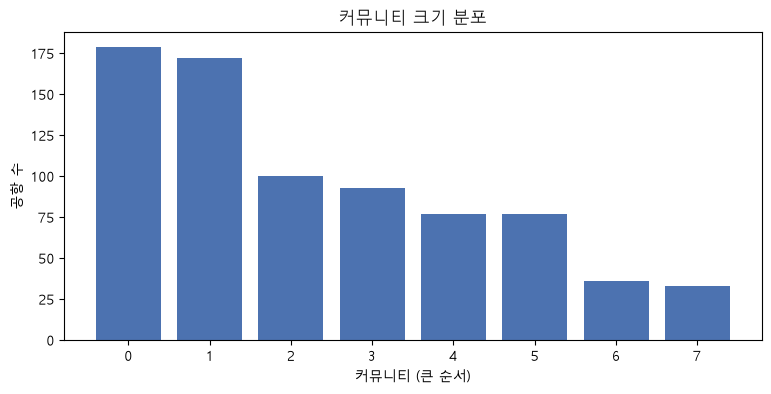

In [69]:
import platform

import matplotlib.pyplot as plt

# 한글 폰트: 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == "Windows":
    KOREAN_FONT = "Malgun Gothic"
elif platform.system() == "Darwin":          # macOS
    KOREAN_FONT = "AppleGothic"
else:                                        # Linux (Colab 등)
    KOREAN_FONT = "NanumGothic"

plt.rcParams["font.family"] = KOREAN_FONT    # 이후 모든 그림에 이 폰트가 적용된다
plt.rcParams["axes.unicode_minus"] = False   # 마이너스(-) 부호 깨짐 방지

# 1) 커뮤니티 크기 막대. 큰 것부터 세워야 쏠림이 보인다
ordered = sizes.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
# x 는 크기 순위(0부터)다. 커뮤니티 번호는 뜻이 없어 축에 쓰지 않는다
ax.bar(range(len(ordered)), ordered.values, color='#4C72B0')
ax.set_xlabel('커뮤니티 (큰 순서)', fontfamily=KOREAN_FONT)
ax.set_ylabel('공항 수', fontfamily=KOREAN_FONT)
ax.set_title('커뮤니티 크기 분포', fontfamily=KOREAN_FONT)
plt.show()

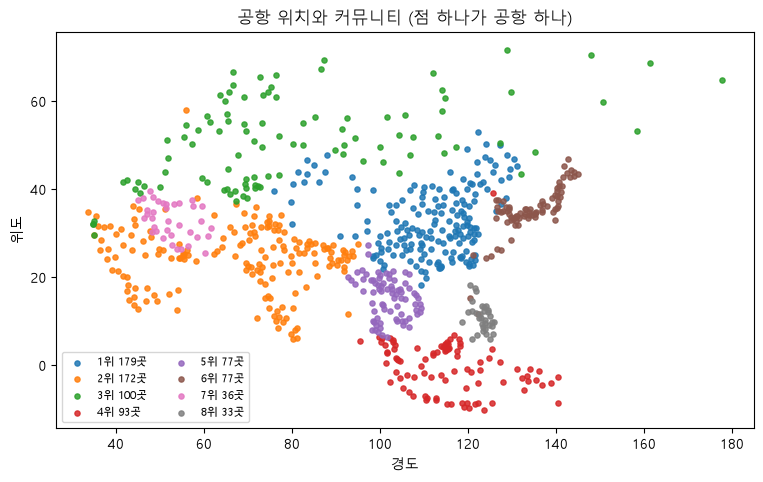

In [70]:
# 2) 위경도 산점도. 색은 커뮤니티다
fig, ax = plt.subplots(figsize=(9, 6))
# 큰 커뮤니티부터 그려야 범례가 크기 순으로 선다
for rank, community_id in enumerate(sizes.index, start=1):
    part = community[community['community'] == community_id]
    ax.scatter(part['lon'], part['lat'], s=14, alpha=0.85, label=f'{rank}위 {len(part)}곳')
# 위도와 경도를 같은 길이로 그려야 대륙 모양이 찌그러지지 않는다
ax.set_aspect('equal')
ax.set_xlabel('경도', fontfamily=KOREAN_FONT)
ax.set_ylabel('위도', fontfamily=KOREAN_FONT)
ax.set_title('공항 위치와 커뮤니티 (점 하나가 공항 하나)', fontfamily=KOREAN_FONT)
ax.legend(prop={'family': KOREAN_FONT, 'size': 8}, ncol=2)
plt.show()

> **알고리즘은 좌표를 보지 않았습니다.** 노선 연결만 보고 나눴는데 **색이 지리적으로 붙어 있습니다.** 3절에서 잰 NMI 0.754 를 눈으로 보는 셈입니다.

동시에 **색 경계가 국경과 정확히 맞지는 않습니다.** 커뮤니티는 나라가 아니라 **권역**이라는 3절의 읽기가 그림에서도 확인됩니다. 색과 순위는 실행할 때마다 달라지니 **모양**을 보세요.

## 6-2. 메타그래프로 커뮤니티 사이의 흐름 보기

<img src="images/교안/커뮤니티_메타그래프.png" width="640">

**메타그래프**는 커뮤니티 하나를 점 하나로 줄인 그림입니다. 점의 크기는 공항 수, 선의 굵기는 두 커뮤니티 사이에 오가는 노선 수입니다. 767개의 점이 손에 꼽을 만큼으로 줄어 **노선망 전체의 뼈대**가 보입니다.

2-2 에서 `write` 로 저장한 `community` 속성을 씁니다. GDS 없이 평범한 Cypher 로 셀 수 있다는 것이 `write` 의 쓸모였습니다.

In [71]:
import networkx as nx

# 1) 메타그래프의 '선' 이 될 값: 커뮤니티와 커뮤니티 사이에 오가는 노선 수
#    a.community <> b.community 가 커뮤니티 안쪽 노선을 빼고 경계를 넘는 것만 남긴다
#    한 줄이 '커뮤니티 source 에서 커뮤니티 target 으로 가는 노선 routes 편' 이 된다
meta_rows = run_cypher('''
    MATCH (a:Airport)-[:ROUTE]->(b:Airport)
    WHERE a.community <> b.community
    RETURN a.community AS source, b.community AS target, count(*) AS routes''')

# 2) 메타그래프의 '점 크기' 가 될 값: 커뮤니티마다 공항이 몇 곳인지
#    2-1 의 sizes 를 쓰지 않는 이유는 그것이 stream(저장하지 않는 실행)의 결과라 번호가
#    지금과 다르기 때문이다. 2-2 에서 write 로 저장한 community 를 읽어 1) 과 짝을 맞춘다
sizes_now = pd.Series(
    {r['community']: r['airports'] for r in run_cypher(
        'MATCH (a:Airport) RETURN a.community AS community, count(*) AS airports')})

# 3) 두 결과를 networkx 그래프 하나로 조립한다. 커뮤니티가 점, 커뮤니티 사이 노선이 선이다
meta = nx.Graph()   # 무방향 그래프라 (5, 8) 과 (8, 5) 를 같은 선으로 본다
# 점을 먼저 놓는다. 공항 수를 점에 달아 두면 다음 셀이 그 값으로 점 크기를 정한다
for community_id, airports in sizes_now.items():
    meta.add_node(community_id, airports=int(airports))
# meta_rows 는 방향별이라 5 -> 8 과 8 -> 5 가 따로 온다. 무방향에서는 둘이 같은 선이라
# 그냥 add_edge 하면 나중 값이 앞의 값을 덮어써 절반이 사라진다. 그래서 직접 더한다
for r in meta_rows:
    # 이미 놓인 선이면 지금까지 쌓인 노선 수를 꺼내고, 처음 놓는 선이면 0 에서 시작한다
    before = meta.edges[r['source'], r['target']]['routes'] if meta.has_edge(
        r['source'], r['target']) else 0
    meta.add_edge(r['source'], r['target'], routes=before + r['routes'])
# 점은 커뮤니티 수, 선은 노선이 오가는 커뮤니티 쌍의 수다
print('메타그래프 노드:', meta.number_of_nodes(), '· 선:', meta.number_of_edges())

메타그래프 노드: 7 · 선: 20


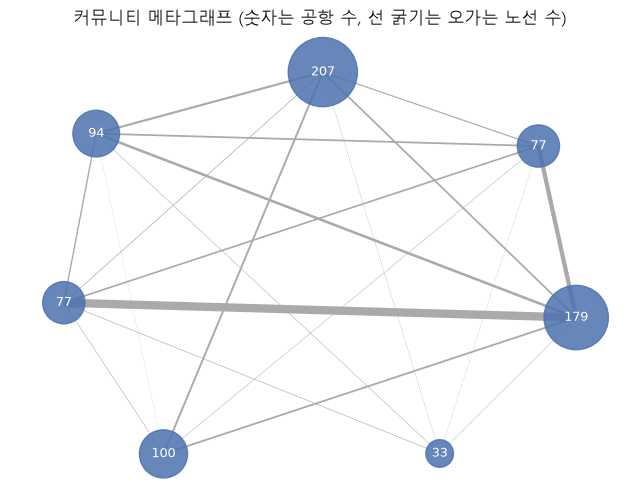

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
# seed 로 배치를 고정해 다시 그려도 같은 모양이 나온다
pos = nx.spring_layout(meta, seed=42, k=1.2)
airports_of = [meta.nodes[n]['airports'] for n in meta.nodes()]
routes_of = [meta.edges[e]['routes'] for e in meta.edges()]
biggest_flow = max(routes_of)
nx.draw_networkx_edges(meta, pos, ax=ax, edge_color='#AAAAAA',
                       width=[6 * m / biggest_flow for m in routes_of])
nx.draw_networkx_nodes(meta, pos, ax=ax, node_color='#4C72B0',
                       node_size=[12 * p for p in airports_of], alpha=0.85)
# 번호에는 뜻이 없어 점 안에는 공항 수를 쓴다
nx.draw_networkx_labels(meta, pos, ax=ax, font_size=9, font_color='white',
                        labels={n: str(meta.nodes[n]['airports']) for n in meta.nodes()})
ax.set_title('커뮤니티 메타그래프 (숫자는 공항 수, 선 굵기는 오가는 노선 수)',
             fontfamily=KOREAN_FONT)
ax.axis('off')
plt.show()

> 커뮤니티끼리는 **대부분 이어져 있습니다.** 앞 셀에서 찍은 `메타그래프 노드` 와 `선` 두 수를 견줘 보세요(노드가 n 개면 쌍은 n x (n - 1) / 2 개입니다). 권역이 달라도 큰 공항끼리는 노선이 오가기 때문입니다.

그래서 읽을 것은 **이어졌는가가 아니라 선 굵기**이고, 굵은 선 몇 개가 이 노선망의 큰 흐름입니다.

큰 그래프는 **먼저 줄이고 나서 그립니다.** 집계(메타그래프)·표본(상위 몇 개만)·요약(막대·산점도) 세 가지입니다.

### 🖐️ 함께 따라하기: 다섯 부서 부분망의 커뮤니티 크기 그리기

`team_community` 의 커뮤니티 크기를 **막대그래프**로 그리세요. 큰 순서로 세우고, 제목·축 라벨을 한글로 답니다(`fontfamily=KOREAN_FONT` 를 잊지 마세요).

**확인 기준**: 막대가 **5개** 서고, 높이는 **51·45·38·32·28** 입니다. 항공 노선망과 달리 **크기가 고르게 나뉘어** 있습니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) team_community['community'].value_counts() 를 내림차순 정렬한다
# 2) fig, ax = plt.subplots() 로 새 그림을 만든다 (앞 그림에 겹쳐 그리지 않도록)
# 3) ax.bar 로 막대를 그리고 제목, 축 라벨에 fontfamily=KOREAN_FONT 를 준다

### ✅ 바로 확인 퀴즈

**1.** 공항 767곳짜리 노선망을 `spring_layout` 으로 그대로 그리면 무엇이 문제인가요?

<details><summary>정답 보기</summary>

점과 선이 겹쳐 **아무것도 읽히지 않습니다.** 그리기 전에 집계·표본·요약으로 먼저 줄여야 합니다. 위경도 산점도가 읽혔던 것은 **선을 하나도 그리지 않았기** 때문이기도 합니다.

</details>

**2.** 메타그래프에서 두 점을 잇는 선이 굵다는 것은 무슨 뜻인가요?

<details><summary>정답 보기</summary>

두 커뮤니티 **사이에 오가는 노선이 많다**는 뜻입니다. 서로 다른 권역인데 굵게 이어져 있다면 그 사이에 환승 거점이 있을 가능성이 큽니다.

</details>

---
## 🚀 응용 클론코딩: 커뮤니티 한 줄 요약 만들기

커뮤니티 번호를 넣으면 요약을 사전으로 돌려주는 `describe_community(community_id)` 를 만드세요.

사전의 키는 `community`, `airports`, `top_country`, `hub` 네 개입니다. `top_country` 는 공항이 가장 많은 국가·지역, `hub` 는 그 커뮤니티에서 **차수가 가장 큰 공항**의 `iata` 입니다.

6-2 의 `sizes_now` 로 **가장 큰 커뮤니티**과 **가장 작은 커뮤니티**에 각각 적용해 출력하세요.

In [ ]:
# 🚀 응용 (아래 순서대로 직접 작성해 보세요)
# 1) def describe_community(community_id): 로 함수를 만든다
# 2) 첫 줄에서 community_id 를 int() 로 감싼다
#    (판다스 정수를 그대로 넘기면 드라이버가 받지 못한다)
# 3) a.community = $community_id 인 공항의 iata, country, 차수를 차수 내림차순으로 받는다
#    (차수는 COUNT { (a)--() } 로 센다)
# 4) community, airports, top_country, hub 네 키를 가진 사전을 돌려준다
# 5) sizes_now.idxmax(), sizes_now.idxmin() 으로 가장 큰 커뮤니티와 가장 작은 커뮤니티에
#    각각 적용해 출력한다

---
## 이번 강의 정리

| 한 일 | 쓴 것 | 기억할 것 |
|---|---|---|
| 무방향 투영 | `gds.graph.project` + `orientation: 'UNDIRECTED'` | 관계 수가 두 배로 나오는 게 정상. 차수는 상대 공항 수와 다르다. Leiden 은 방향 투영을 거부한다 |
| 커뮤니티 찾기 | `gds.leiden.stream` / `.write` | 개수보다 **크기 분포**를 먼저 본다 |
| 정답 대조 | `pd.crosstab`, 순도, `normalized_mutual_info_score` | 정답이 있으면 반드시 잰다. 안 맞는 부분이 오히려 발견이다 |
| 알고리즘 비교 | `gds.modularity.stats` | 라벨 전파는 큰 커뮤니티로 쏠리고 적재마다 답이 달라진다. 최대 크기를 확인한다 |
| 요약만 받기 | `gds.leiden.stats` | 모듈러리티 하나만 필요하면 저장도 재투영도 없이 |
| 관계의 숫자 반영 | `relationshipWeightProperty` | 커뮤니티에서는 클수록 **가깝다**. 최단 경로에서는 반대다. 값이 어느 쪽으로 움직일지는 재 봐야 안다 |
| 재현 | `randomSeed` + `concurrency: 1` | `randomSeed` 만으로는 고정되지 않고, 새로 적재하면 또 달라진다 |
| 커뮤니티 수 조절 | Leiden 의 `gamma` | 올리면 잘게, 내리면 크게. 정답 개수에 맞추는 것과 잘 맞는 것은 다르다 |
| 큰 그래프 그리기 | 막대·산점도·메타그래프 | **먼저 줄이고 나서 그린다** |

**오늘의 발견.** 알고리즘이 찾은 커뮤니티는 **나라가 아니라 권역**입니다. 국가·지역 47개에 커뮤니티는 5개에서 9개, NMI 는 0.754 안팎입니다. 어긋난 자리가 국경보다 **노선이 실제로 어떻게 이어져 있는지**를 보여 줍니다.

- **시연**: OpenFlights `airports.dat`·`routes.dat`(ODbL). 노선은 **2014년 6월에 갱신이 멈춘 자료**라 시간표가 아니라 노선 유무만 담겨 있습니다.
- **따라하기**: SNAP `email-Eu-core`(라이선스 표기 없음, 학습용). 유럽 연구기관의 사내 메일을 익명화한 공개 데이터입니다.

## ⏭️ 예고: 다음 교시

커뮤니티를 찾았으니 이제 **공항 하나하나의 관계**를 봅니다.

- **노드 유사도**: 인천(ICN)과 **노선 집합이 닮은 공항**은 어디인가.
- **최단 경로**: 인천에서 어느 공항까지 **몇 편**에 닿는가.
- **세 잣대**: 같은 목적지라도 **편 수 최소·거리 최소·시간 최소**가 서로 다른 길입니다. 오늘 실어 둔 `km`·`hours` 를 거기서 씁니다.